## Protein Language Model Embeddings with ESM2

In the next section, the notebook moves from manual sequence encoding to learned protein representations using ESM2.  
Unlike one hot encoding, ESM2 embeddings capture contextual and biochemical relationships between amino acids.

## Imports

The following libraries are used for tensor operations and visualization.

In [1]:
import torch                      # PyTorch tensors
import torch.nn.functional as F   # One-hot encoding functions

import seaborn as sns             # Statistical visualizations
import matplotlib.pyplot as plt   # Plotting

## Human Preproinsulin Sequence

Human preproinsulin is the precursor form of insulin.  
Its amino acid sequence is represented here using the standard single-letter amino acid code.

In [2]:
# Human preproinsulin amino acid sequence (single-letter code)
# This is the full precursor protein synthesized from the INS gene.
# It includes:
# 1. Signal peptide
# 2. B chain
# 3. C-peptide
# 4. A chain

human_preproinsulin = (
    "MALWMRLLPLLALLALWGPDPAAA"
    "FVNQHLCGSHLVEALYLVCGERGFFYTPKT"
    "RREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKR"
    "GIVEQCCTSICSLYQLENYCN"
)

# Count total number of amino acids in the precursor protein
sequence_length = len(human_preproinsulin)

# Display result
print(f"Human preproinsulin length: {sequence_length} amino acids")

Human preproinsulin length: 110 amino acids


## Standard Amino Acid Alphabet

The standard protein alphabet contains 20 amino acids, each represented by a single-letter code.

In [3]:
# Standard 20 amino acids (single-letter codes)
amino_acids = [
    "R",  # Arginine
    "H",  # Histidine
    "K",  # Lysine
    "D",  # Aspartic acid
    "E",  # Glutamic acid
    "S",  # Serine
    "T",  # Threonine
    "N",  # Asparagine
    "Q",  # Glutamine
    "G",  # Glycine
    "P",  # Proline
    "C",  # Cysteine
    "A",  # Alanine
    "V",  # Valine
    "I",  # Isoleucine
    "L",  # Leucine
    "M",  # Methionine
    "F",  # Phenylalanine
    "Y",  # Tyrosine
    "W",  # Tryptophan
]

print(f"Standard amino acid count: {len(amino_acids)} / 20")

Standard amino acid count: 20 / 20


## Amino Acid to Index Mapping

To prepare protein sequences for machine learning, each amino acid is mapped to a numeric index.

In [4]:
# Create mapping: amino acid letter -> numeric index
amino_acid_to_index = {
    aa: idx
    for idx, aa in enumerate(amino_acids)
}

print("Amino acid to index mapping:")
print(amino_acid_to_index)

Amino acid to index mapping:
{'R': 0, 'H': 1, 'K': 2, 'D': 3, 'E': 4, 'S': 5, 'T': 6, 'N': 7, 'Q': 8, 'G': 9, 'P': 10, 'C': 11, 'A': 12, 'V': 13, 'I': 14, 'L': 15, 'M': 16, 'F': 17, 'Y': 18, 'W': 19}


## Toy Protein Example

Before encoding the full insulin precursor, a short toy protein sequence is used to demonstrate the workflow.

In [11]:
# Example toy protein sequence
toy_protein = "MARTKQLEGV"

# Convert amino acid chain to indices
toy_protein_indices = [ amino_acid_to_index[aa] for aa in toy_protein ]

print(f"Protein sequence: {toy_protein}")
print(f"Sequence length: {len(toy_protein)}")
print(f"Encoded indices: {toy_protein_indices}")

Protein sequence: MARTKQLEGV
Sequence length: 10
Encoded indices: [16, 12, 0, 6, 2, 8, 15, 4, 9, 13]


## One-Hot Encoding

Each amino acid index is transformed into a one-hot vector of length 20.  
This creates a matrix with one row per sequence position and one column per amino acid type.

In [10]:
# One-hot encode
toy_protein_one_hot = F.one_hot(
    torch.tensor(toy_protein_indices),
    num_classes=20
).float()

print(toy_protein_one_hot)
print(toy_protein_one_hot.shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0.]])
torch.Siz

## Heatmap Visualization

The one-hot encoded toy protein is visualized as a heatmap.  
Rows represent sequence positions, and columns represent amino acid categories.

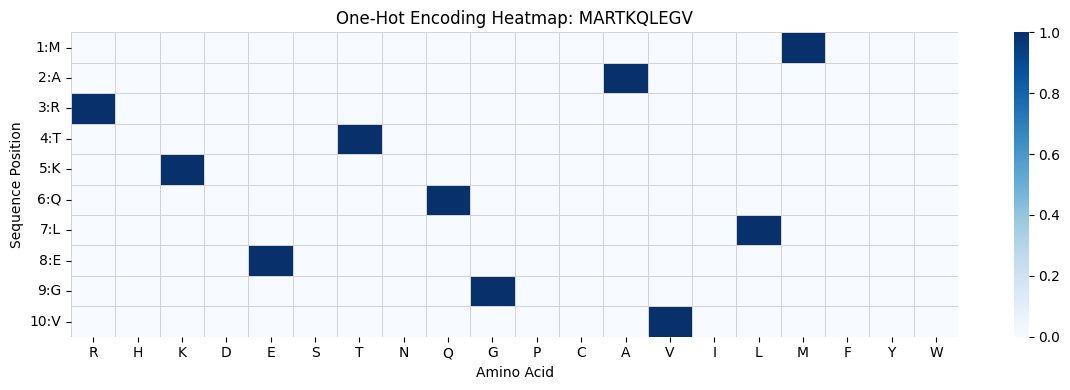

In [7]:
# Convert PyTorch tensor to NumPy for Seaborn / Matplotlib
data = toy_protein_one_hot.numpy()

# Create figure
plt.figure(figsize=(12, 4))

# Plot one-hot encoded sequence as heatmap
sns.heatmap(
    data,
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="lightgray"
)

# Titles and axis labels
plt.title(f"One-Hot Encoding Heatmap: {toy_protein}")
plt.xlabel("Amino Acid")
plt.ylabel("Sequence Position")

# Column labels = 20 amino acid letters
plt.xticks(
    ticks=[i + 0.5 for i in range(len(amino_acids))],
    labels=amino_acids,
    rotation=0
)

# Row labels = sequence position + amino acid letter
plt.yticks(
    ticks=[i + 0.5 for i in range(len(toy_protein))],
    labels=[f"{i+1}:{aa}" for i, aa in enumerate(toy_protein)],
    rotation=0
)

# Improve spacing and show plot
plt.tight_layout()
plt.show()

## Protein Language Model Embeddings with ESM2

In the next section, the notebook moves from manual sequence encoding to learned protein representations using ESM2.  
Unlike one hot encoding, ESM2 embeddings capture contextual and biochemical relationships between amino acids.